## 1. What this notebook computes

The field equations of gravity that the author's theory uses (the Lovelock
equations) are built with one combinatorial tool: the **generalized Kronecker
delta**. The author defined it in his Mathematica notebook as the determinant of
a small matrix of zeros and ones; the Revision record computes it with a fast
program called GKD. This notebook

- reads the author's definition from the Revision record and writes it in Python
  literally (a Leibniz determinant), and again as the fast rule of GKD;
- reproduces every example of the record and the record's counts of the values
  $+1$, $-1$ and $0$ for all pairs of index lists of length 1, 2 and 3 over the
  eight coordinates $x_1, \dots, x_8$, and checks all 16,777,216 pairs of length
  4, as the record's self-test did;
- proves and checks a formula for the number of nonzero values, and that nine
  indices in eight dimensions always give 0;
- proves and checks the contraction identity, which explains the factors 6, 4
  and 2 that appear in the record's Lovelock trace identities;
- shows that the Levi-Civita symbol is a special generalized delta and checks
  the product formula of two Levi-Civita symbols, the second route of the
  author's notebook.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01c (The generalized Kronecker delta as a determinant) is the file
`Revision/textbook/notebooks/01c_generalized_delta.ipynb` of the repository Dirac_claude.
It reads the author's definition of the generalized Kronecker delta from the Revision
record (the determinant of the matrix of ordinary Kronecker deltas of two index lists),
writes it in Python twice, literally with the Leibniz determinant and as the fast rule of
the Revision program GKD (zero for a repeated or missing index, otherwise the sign of a
permutation), reproduces the examples and the exhaustive counts of the Revision record
for index lists of length 1 to 4 over the eight coordinates x1 to x8 (16,777,216 pairs
for length 4), proves and checks the counting formula for the nonzero values, the
vanishing for nine indices in eight dimensions, the two-index formula, the contraction
identity that gives the factors 6, 4 and 2 of the Lovelock trace identities, and the
product formula of two Levi-Civita symbols that the author's notebook also uses, with
heat maps and plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01c_generalized_delta.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01c_generalized_delta.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01c_generalized_delta.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/01c.captions.json`
- `Revision/textbook/figures/01c_1_outer_matrices.png`
- `Revision/textbook/figures/01c_2_two_index_table.png`
- `Revision/textbook/figures/01c_3_value_counts.png`
- `Revision/textbook/figures/01c_4_nonzero_fraction.png`
- `Revision/textbook/figures/01c_5_contraction_factor.png`
- `Revision/textbook/figures/01c_6_levi_civita.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 28 CHECKS PASSED (notebook 01c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01c_generalized_delta.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below Revision/gkd_lovelock or Revision/algebra: the
  notebook reads Revision records of the repository; your copy of the repository is
  incomplete. Download it again with git clone and open the notebook inside the new copy.
- the computer becomes slow during the cell that checks all 16,777,216 pairs: that cell
  needs about 250 MB of memory and 10 to 30 seconds; close other programs and run the
  cell again. It works in blocks of 1,048,576 pairs, so it never needs more memory than
  that.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01c (The generalized Kronecker delta as a determinant) is the file
# Revision/textbook/notebooks/01c_generalized_delta.ipynb of the repository Dirac_claude.
# It reads the author's definition of the generalized Kronecker delta from the Revision
# record (the determinant of the matrix of ordinary Kronecker deltas of two index lists),
# writes it in Python twice, literally with the Leibniz determinant and as the fast rule
# of the Revision program GKD (zero for a repeated or missing index, otherwise the sign
# of a permutation), reproduces the examples and the exhaustive counts of the Revision
# record for index lists of length 1 to 4 over the eight coordinates x1 to x8 (16,777,216
# pairs for length 4), proves and checks the counting formula for the nonzero values, the
# vanishing for nine indices in eight dimensions, the two-index formula, the contraction
# identity that gives the factors 6, 4 and 2 of the Lovelock trace identities, and the
# product formula of two Levi-Civita symbols that the author's notebook also uses, with
# heat maps and plots. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy and matplotlib; the other packages run Jupyter, the program that shows
# and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01c_generalized_delta.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01c_generalized_delta.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01c_generalized_delta.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/01c.captions.json
# - Revision/textbook/figures/01c_1_outer_matrices.png
# - Revision/textbook/figures/01c_2_two_index_table.png
# - Revision/textbook/figures/01c_3_value_counts.png
# - Revision/textbook/figures/01c_4_nonzero_fraction.png
# - Revision/textbook/figures/01c_5_contraction_factor.png
# - Revision/textbook/figures/01c_6_levi_civita.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 28 CHECKS PASSED (notebook 01c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01c_generalized_delta.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below Revision/gkd_lovelock or Revision/algebra: the
#   notebook reads Revision records of the repository; your copy of the repository is
#   incomplete. Download it again with git clone and open the notebook inside the new
#   copy.
# - the computer becomes slow during the cell that checks all 16,777,216 pairs: that cell
#   needs about 250 MB of memory and 10 to 30 seconds; close other programs and run the
#   cell again. It works in blocks of 1,048,576 pairs, so it never needs more memory than
#   that.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01c"  # this notebook: chapter 01, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Label**: a name of a coordinate, here $x_1, \dots, x_8$. The computer often
  numbers them $0, \dots, 7$; only the question "are two labels equal?" matters
  below, so the names do not change any result.
- **Index list**: an ordered list of labels, such as $(x_1, x_3, x_3)$; its
  **length** is the number of entries (here 3).
- **Kronecker delta** $\delta(a, b)$: 1 if the labels $a$ and $b$ are equal, 0
  otherwise (also written $\delta^a_b$).
- **Generalized Kronecker delta** of a lower list $(l_1, \dots, l_p)$ and an upper
  list $(u_1, \dots, u_p)$ of the same length $p$: the determinant of the
  $p \times p$ matrix whose entry in row $i$ and column $j$ is
  $\delta(l_i, u_j)$; written $\delta^{u_1 \dots u_p}_{l_1 \dots l_p}$.
- **Outer**: Mathematica's name for the operation that builds that matrix,
  `Outer[delta, lower, upper]`. The author's function is called
  `k\[Delta]` (Mathematica's plain-text spelling of "k" followed by the Greek
  letter delta).
- **GKD**: the Revision record's program (written in the language Rust) that
  computes the generalized delta without a determinant.
- **Permutation, inversion, sign**: a re-ordering of a list; a pair of places in
  the wrong order; $(-1)^{\text{number of inversions}}$.
- **Exhaustive check**: a check of *every* possible case, not of examples.
- **Vectorized computation**: numpy applies one operation to millions of numbers
  in an array at once, much faster than a Python loop.
- **Pigeonhole principle**: if more than $n$ objects are put into $n$ boxes, some
  box gets at least two of them.
- **Contraction**: setting an upper and a lower index equal and adding over all
  values of that index (the summation convention).
- **Levi-Civita symbol** $\varepsilon_{i_1 \dots i_n}$: the sign of the list
  $(i_1, \dots, i_n)$ if it is a re-ordering of all $n$ labels, and 0 otherwise.
- **Falling factorial** $n!/(n-p)! = n (n-1) \cdots (n-p+1)$: the number of ways
  to choose $p$ different labels from $n$ in order (`math.perm(n, p)`).
- **Lovelock tensors**: combinations of the curvature of spacetime that enter the
  field equations of gravity in more than four dimensions; the Revision record
  computes three of them for the author's metric, with GKD as the weight of every
  term.

## 4. The physical and mathematical situation

The author's Mathematica notebook defines (input cell In[54], stored in the file
as In[87]):

`k\[Delta][lower_, upper_] /; Length[lower] == Length[upper] :=
Det[Outer[delta, lower, upper]]`

In words: for two index lists of equal length, build the matrix
$M_{ij} = \delta(l_i, u_j)$ and take its determinant. For one index this is the
ordinary Kronecker delta. For two indices the $2 \times 2$ determinant gives

$$\delta^{u_1 u_2}_{l_1 l_2} = \delta(l_1, u_1)\,\delta(l_2, u_2)
- \delta(l_1, u_2)\,\delta(l_2, u_1).$$

The Revision program GKD avoids the determinant with a proof in four cases
(written in the file Revision/gkd_lovelock/code/src/gkd.rs):

- (a) two equal lower labels make two equal rows of $M$, so $\det M = 0$;
- (b) two equal upper labels make two equal columns, so $\det M = 0$;
- (c) a lower label that is not among the upper labels makes a row of zeros, so
  $\det M = 0$;
- (d) otherwise both lists consist of the same $p$ different labels; each $l_i$
  equals exactly one $u_{\sigma(i)}$, $M$ is the permutation matrix of $\sigma$,
  and $\det M = \mathrm{sign}(\sigma)$ (only one term of the Leibniz formula is
  not zero).

In the Lovelock tensors of the author's theory the generalized delta appears with
$2k + 1$ indices, $k = 1, 2, 3$, in the eight dimensions $x_1, \dots, x_8$:
$P_{(k)}{}^h{}_j = \delta^{h h_1 \dots h_{2k}}_{j j_1 \dots j_{2k}}
R^{j_1 j_2}{}_{h_1 h_2} \cdots$ (summation convention). Two facts of this
notebook matter there: with 9 indices ($k = 4$) the delta is always 0, so the
sum stops at $k = 3$; and contracting $h$ with $j$ multiplies by $8 - 2k$, which
is why the record's trace identities read $\sum_h P_{(k)}{}^h{}_h = (8 - 2k)
L_{(k)}$ with the factors 6, 4 and 2.

## 5. The author's definition, read from the record

The next cell reads two files of the Revision record. The file
PROVENANCE_OF_THE_COMPUTATION.md records the author's definition verbatim, with
the Greek letter $\delta$; this notebook is written in plain ASCII, so the letter
is typed as its code `\u03b4`. The file notebook-input-cells.txt lists the input
cells of the author's notebook, each under the label stored in the file; the cell
finds the definition (In[87]), the first cell of the author's second route
(In[32], a product of two Levi-Civita tensors, section 15 of this notebook) and
the cell that declares the metric $g$ used by that route (In[29]), and prints
them, with the Greek letter written as `\[Delta]`. `re.search` looks for a
pattern in a text; `HoldForm[...]` is how the record wraps every cell.

In [2]:
import itertools  # all lists of labels, all permutations
import json  # reads the JSON reports of the Revision record
import math  # factorials
import re  # finds patterns in texts

import numpy as np  # arrays: many index lists at once

DELTA = "\u03b4"  # the Greek letter delta, written with its code
definition = ("k" + DELTA + "[lower_, upper_] /; Length[lower] == Length[upper] := "
              "Det[Outer[delta, lower, upper]]")
provenance_path = repository_file("Revision/gkd_lovelock/results/"
                                  "PROVENANCE_OF_THE_COMPUTATION.md")
provenance = provenance_path.read_text(encoding="utf-8")
check(definition in provenance, "the record holds the author's definition verbatim",
      record="Revision/gkd_lovelock/results/PROVENANCE_OF_THE_COMPUTATION.md")
input_cells = repository_file("Revision/gkd_lovelock/results/"
                              "notebook-input-cells.txt").read_text(encoding="utf-8")
found = {}
for line in input_cells.splitlines():
    for label in ("In[87]:=", "In[32]:=", "In[29]:="):
        if line.startswith(label):
            found[label] = re.search(r"HoldForm\[(.*)\]", line).group(1)
for label in ("In[87]:=", "In[32]:=", "In[29]:="):
    plain_text = found[label].replace(DELTA, "\\[Delta]")  # Mathematica's spelling
    say(f"author's cell {label} {plain_text}")
metric_cell = found["In[29]:="]  # kept for section 15 (the declaration of g)
check("Det[Outer[delta, lower, upper]]" in found["In[87]:="] and
      "epsilong" in found["In[32]:="] and "(8 - 1)!" in found["In[32]:="],
      "the author's notebook defines the delta as a determinant (In[87]) and "
      "also uses a product of two Levi-Civita tensors (In[32])",
      record="Revision/gkd_lovelock/results/notebook-input-cells.txt")

PASS the record holds the author's definition verbatim
     reproduces Revision/gkd_lovelock/results/PROVENANCE_OF_THE_COMPUTATION.md
author's cell In[87]:= Clear[k\[Delta]]; k\[Delta][lower_, upper_] /; Length[lower] ==
    Length[upper] := Det[Outer[delta, lower, upper]]
author's cell In[32]:= delta11 = Simplify[(epsilong[-a, -f, -i, -j, -k, -l, -m,
    -n]*epsilong[b, f, i, j, k, l, m, n])/(8 - 1)!]
author's cell In[29]:= DefMetric[{4, 4, 0}, g[-a, -b], CD, {";", "D"}, WeightedWithBasis
    -> AIndex]
PASS the author's notebook defines the delta as a determinant (In[87]) and also uses a
    product of two Levi-Civita tensors (In[32])
     reproduces Revision/gkd_lovelock/results/notebook-input-cells.txt


## 6. The generalized Kronecker delta, literally

The next cell writes the author's definition in Python, word for word:

- `kronecker(a, b)` is the ordinary Kronecker delta of two labels;
- `outer_matrix(lower, upper)` is `Outer[delta, lower, upper]`;
- `leibniz_det(rows)` is the determinant by the Leibniz formula; the list of the
  permutations of each size and their signs is computed once and kept in the
  dictionary `SIGNED`, because the same lists are needed millions of times;
- `kdelta_literal(lower, upper)` refuses lists of different lengths (the
  author's definition then stays unevaluated) and otherwise returns the
  determinant.

The labels may be any names: here the strings `"x1"`, ..., `"x8"`.

In [3]:
def kronecker(a, b):
    """The ordinary Kronecker delta of two labels: 1 if they are equal, else 0."""
    return 1 if a == b else 0


def outer_matrix(lower, upper):
    """Outer[delta, lower, upper]: row i, column j is kronecker(lower[i], upper[j])"""
    return [[kronecker(l_label, u_label) for u_label in upper] for l_label in lower]


def inversions(order):
    """The number of pairs of places i < j whose entries stand in the wrong order."""
    return sum(1 for i in range(len(order)) for j in range(i + 1, len(order))
               if order[i] > order[j])


def sign(order):
    """+1 for an even number of inversions, -1 for an odd number."""
    return 1 if inversions(order) % 2 == 0 else -1


SIGNED = {}  # size n -> list of (permutation, its sign), computed once per size


def signed_permutations(n):
    if n not in SIGNED:
        SIGNED[n] = [(order, sign(order)) for order in itertools.permutations(range(n))]
    return SIGNED[n]


def leibniz_det(rows):
    """The Leibniz determinant of a square matrix given as a list of rows."""
    total = 0
    for order, order_sign in signed_permutations(len(rows)):
        term = order_sign
        for i, column in enumerate(order):
            term *= rows[i][column]
            if term == 0:  # one factor 0 makes the whole term 0: stop early
                break
        total += term
    return total


def kdelta_literal(lower, upper):
    """The author's k-delta: Det[Outer[delta, lower, upper]] for equal lengths."""
    if len(lower) != len(upper):
        raise ValueError("the two index lists must have the same length")
    return leibniz_det(outer_matrix(lower, upper))


def signed(value):
    """A value +1, -1 or 0 as the text "+1", "-1" or "0"."""
    return f"{value:+d}" if value else "0"


same = kdelta_literal(("x1",), ("x1",))  # lists of length 1: ("x1",) has one entry
different = kdelta_literal(("x1",), ("x2",))
say(f"one index: delta(x1, x1) = {same}, delta(x1, x2) = {different}")
check(same == 1 and different == 0,
      "for one index the generalized delta is the ordinary Kronecker delta")

one index: delta(x1, x1) = 1, delta(x1, x2) = 0
PASS for one index the generalized delta is the ordinary Kronecker delta


The next cell draws the matrix `Outer[delta, lower, upper]` for five pairs of
index lists of length 3 and writes the determinant in each title. The rows belong
to the lower list, the columns to the upper list; a dark square is a 1. They are
the four cases of the proof in section 4: the same list twice (the identity
matrix, $+1$); the upper list turned around cyclically (a permutation with two
inversions, $+1$); two upper labels exchanged (one inversion, $-1$); a repeated
lower label (two equal rows, 0); a lower label $x_4$ missing from the upper list
(a row of zeros, 0).

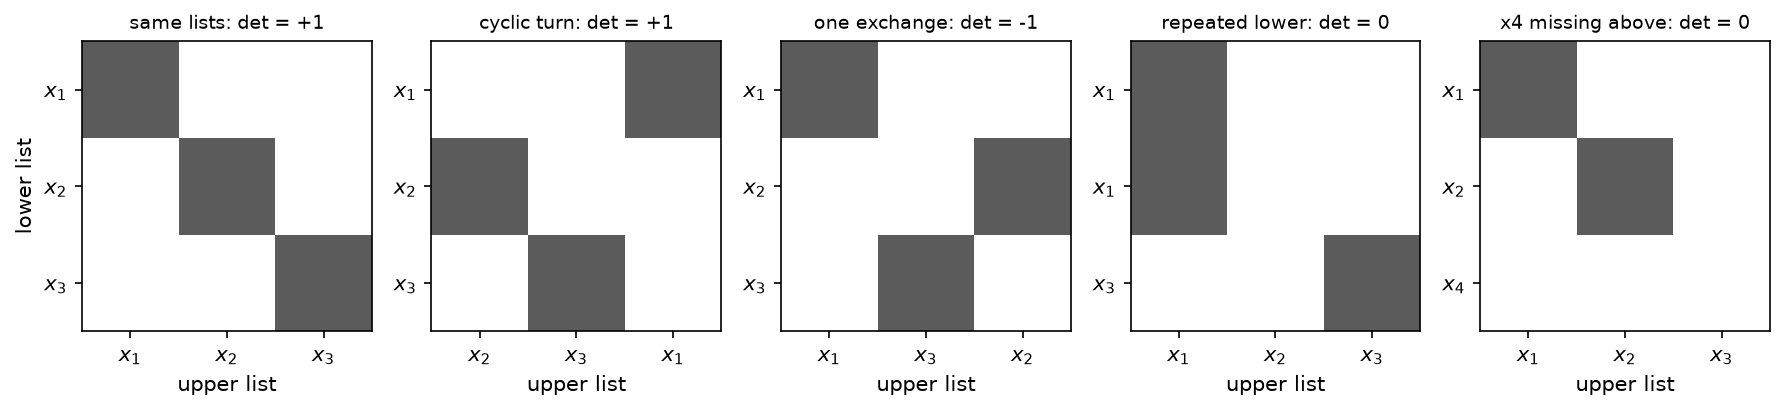

Figure 01c.1 saved as Revision/textbook/figures/01c_1_outer_matrices.png
PASS the five pictured examples give +1, +1, -1, 0, 0


In [4]:
examples = [(("x1", "x2", "x3"), ("x1", "x2", "x3"), "same lists"),
            (("x1", "x2", "x3"), ("x2", "x3", "x1"), "cyclic turn"),
            (("x1", "x2", "x3"), ("x1", "x3", "x2"), "one exchange"),
            (("x1", "x1", "x3"), ("x1", "x2", "x3"), "repeated lower"),
            (("x1", "x2", "x4"), ("x1", "x2", "x3"), "x4 missing above")]
fig, axes = plt.subplots(1, 5, figsize=(12.0, 3.4))
for ax, (lower, upper, what) in zip(axes, examples):
    matrix = np.array(outer_matrix(lower, upper))
    ax.imshow(matrix, cmap="Greys", vmin=0, vmax=1.4)
    ax.grid(False)
    ax.set_xticks(range(3), [f"${u[0]}_{u[1]}$" for u in upper])  # "x1" -> x_1
    ax.set_yticks(range(3), [f"${l_label[0]}_{l_label[1]}$" for l_label in lower])
    ax.set_xlabel("upper list")
    ax.set_title(f"{what}: det = {signed(kdelta_literal(lower, upper))}", fontsize=9)
axes[0].set_ylabel("lower list")
fig.tight_layout()
save_figure(fig, "outer_matrices",
            "The matrix Outer of ordinary Kronecker deltas for five pairs of index "
            "lists of length 3: rows are the lower list, columns the upper list, a "
            "dark square is an entry 1 and a white square an entry 0; the title "
            "gives the determinant, which is the generalized Kronecker delta. From "
            "left to right: equal lists (identity matrix, $+1$), a cyclic turn "
            "($+1$), one exchange ($-1$), a repeated lower label (two equal rows, "
            "0) and a lower label missing from the upper list (a row of zeros, 0).")
values = [kdelta_literal(lower, upper) for lower, upper, _ in examples]
check(values == [1, 1, -1, 0, 0], "the five pictured examples give +1, +1, -1, 0, 0")

## 7. The fast rule of the program GKD

The next cell writes the four cases of the proof as the Python function
`gkd_rule`, line by line as the Rust function `GKD` of the record does it: first
it notes the place of every upper label (and returns 0 at a repeated upper label,
case b); then for every lower label it looks up its place among the upper labels
(returning 0 if it is missing, case c, or if that place was taken already, which
means a repeated lower label, case a); the places form the permutation
$\sigma$, whose sign is the result (case d). It never builds a matrix.

The cell checks that the rule gives the literal values for the five examples, and
that renaming the labels ($x_k$ to $x_{k+1}$, with $x_8$ to $x_1$) changes no value:
only equal or different matters.

In [5]:
def gkd_rule(lower, upper):
    """The program GKD of Revision/gkd_lovelock/code/src/gkd.rs, in Python."""
    if len(lower) != len(upper):
        raise ValueError("the two index lists must have the same length")
    place = {}  # upper label -> its place 0, 1, ..., p-1
    for j, u_label in enumerate(upper):
        if u_label in place:  # case (b): a repeated upper label
            return 0
        place[u_label] = j
    sigma = []  # sigma[i] = the place of lower[i] among the upper labels
    for l_label in lower:
        if l_label not in place:  # case (c): a lower label missing above
            return 0
        if place[l_label] in sigma:  # case (a): a repeated lower label
            return 0
        sigma.append(place[l_label])
    return sign(sigma)  # case (d): the sign of the permutation sigma


check(all(gkd_rule(lower, upper) == kdelta_literal(lower, upper)
          for lower, upper, _ in examples),
      "the fast rule gives the literal values for the five examples")
renamed = {f"x{k}": f"x{k % 8 + 1}" for k in range(1, 9)}  # x1->x2, ..., x8->x1
two_lists = list(itertools.product([f"x{k}" for k in range(1, 9)], repeat=2))
check(all(gkd_rule(lo, up) == gkd_rule(tuple(renamed[a] for a in lo),
                                       tuple(renamed[b] for b in up))
          for lo in two_lists for up in two_lists),
      "renaming the labels changes no value (all 4096 pairs of length 2)")

PASS the fast rule gives the literal values for the five examples
PASS renaming the labels changes no value (all 4096 pairs of length 2)


## 8. The examples of the record

The next cell reads three reports of the Revision record and repeats their
examples with both functions:

- python-lovelock-report.json, check `gkd_examples`: five values written as
  `kdelta[{1,2},{2,1}] = -1` and so on (labels 1, 2, 3, 4); a regular expression
  (`re.findall`) picks the two lists and the value out of the text;
- wolfram-gkd-report.json, check `definition_unequal_lengths_stay_unevaluated`:
  the values $-1$ and $+1$ of two examples with labels 0, 1, 2, and the refusal
  of lists of different lengths (our functions raise a `ValueError`);
- lovelock-report.json, field `gkdSelfCheck`: the two values that the Rust
  program printed for the lists $(0, 1, 2), (1, 2, 0)$ and $(0, 1), (1, 0)$.

In [6]:
def read_report(name):
    """A JSON report of Revision/gkd_lovelock/results as a Python dictionary."""
    path = repository_file(f"Revision/gkd_lovelock/results/{name}")
    return json.loads(path.read_text(encoding="utf-8"))


def lists_from_text(text):
    """"1,2,3" -> (1, 2, 3)"""
    return tuple(int(part) for part in text.replace(" ", "").split(","))


python_report = read_report("python-lovelock-report.json")
python_checks = {c["name"]: c for c in python_report["checks"]}
pattern = r"kdelta\[\{([\d,]+)\},\{([\d,]+)\}\] = (-?\d+)"
record_examples = re.findall(pattern, python_checks["gkd_examples"]["detail"])
for lower_text, upper_text, value in record_examples:
    lower, upper = lists_from_text(lower_text), lists_from_text(upper_text)
    say(f"lower {lower}, upper {upper}: record {signed(int(value))}, literal "
        f"{signed(kdelta_literal(lower, upper))}, rule {signed(gkd_rule(lower, upper))}")
check(len(record_examples) == 5 and all(
    kdelta_literal(lists_from_text(lo), lists_from_text(up)) == int(v) ==
    gkd_rule(lists_from_text(lo), lists_from_text(up)) for lo, up, v in record_examples),
    "the five examples of the record", record="Revision/gkd_lovelock/results/"
    "python-lovelock-report.json, check gkd_examples")
wolfram_report = read_report("wolfram-gkd-report.json")
wolfram_checks = {c["name"]: c for c in wolfram_report["checks"]}
detail = wolfram_checks["definition_unequal_lengths_stay_unevaluated"]["detail"]
wolfram_pattern = "k" + DELTA + r"\[\{([\d, ]+)\}, \{([\d, ]+)\}\] = ([+-]?\d+)"
wolfram_examples = re.findall(wolfram_pattern, detail)
try:
    kdelta_literal((0,), (0, 1))
    refused = False
except ValueError:  # lists of different lengths are refused
    refused = True
check(refused and len(wolfram_examples) == 2 and all(
    kdelta_literal(lists_from_text(lo), lists_from_text(up)) == int(v)
    for lo, up, v in wolfram_examples),
    "lists of different lengths are refused; the two Wolfram examples",
    record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, check "
    "definition_unequal_lengths_stay_unevaluated")
self_check = read_report("lovelock-report.json")["gkdSelfCheck"]
length3_pair, transposition = self_check["length3Pair"], self_check["transposition"]
say(f"lovelock-report.json gkdSelfCheck: length3Pair = {length3_pair}, "
    f"transposition = {transposition}")
check(self_check["length3Pair"] == gkd_rule((0, 1, 2), (1, 2, 0)) and
      self_check["transposition"] == gkd_rule((0, 1), (1, 0)),
      "the two values printed by the Rust program",
      record="Revision/gkd_lovelock/results/lovelock-report.json, gkdSelfCheck")

lower (1, 2), upper (1, 2): record +1, literal +1, rule +1
lower (1, 2), upper (2, 1): record -1, literal -1, rule -1
lower (1, 1), upper (1, 1): record 0, literal 0, rule 0
lower (1, 2, 3), upper (2, 3, 1): record +1, literal +1, rule +1
lower (1, 2, 3), upper (1, 2, 4): record 0, literal 0, rule 0
PASS the five examples of the record
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    gkd_examples
PASS lists of different lengths are refused; the two Wolfram examples
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, check
    definition_unequal_lengths_stay_unevaluated
lovelock-report.json gkdSelfCheck: length3Pair = 1, transposition = -1
PASS the two values printed by the Rust program
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, gkdSelfCheck


## 9. Two indices: the 64 by 64 table

With two indices over eight labels there are $8^2 = 64$ lower lists and 64 upper
lists, so $64 \cdot 64 = 4096$ values. The next cell computes all of them, checks
the two-term formula
$\delta^{u_1 u_2}_{l_1 l_2} = \delta(l_1, u_1)\delta(l_2, u_2)
- \delta(l_1, u_2)\delta(l_2, u_1)$ for every one of them, counts the values
$+1$ and $-1$ (each must be 56: a list of two *different* labels, $8 \cdot 7 = 56$
of them, gives $+1$ with itself and $-1$ with its reverse), and draws the table.
From here on the labels are the numbers 0 to 7, the computer's names for
$x_1$ to $x_8$.

PASS the two-term formula holds for all 4096 pairs of length 2
values +1: 56, values -1: 56, zeros: 3984
PASS 56 values +1 and 56 values -1 among the 4096


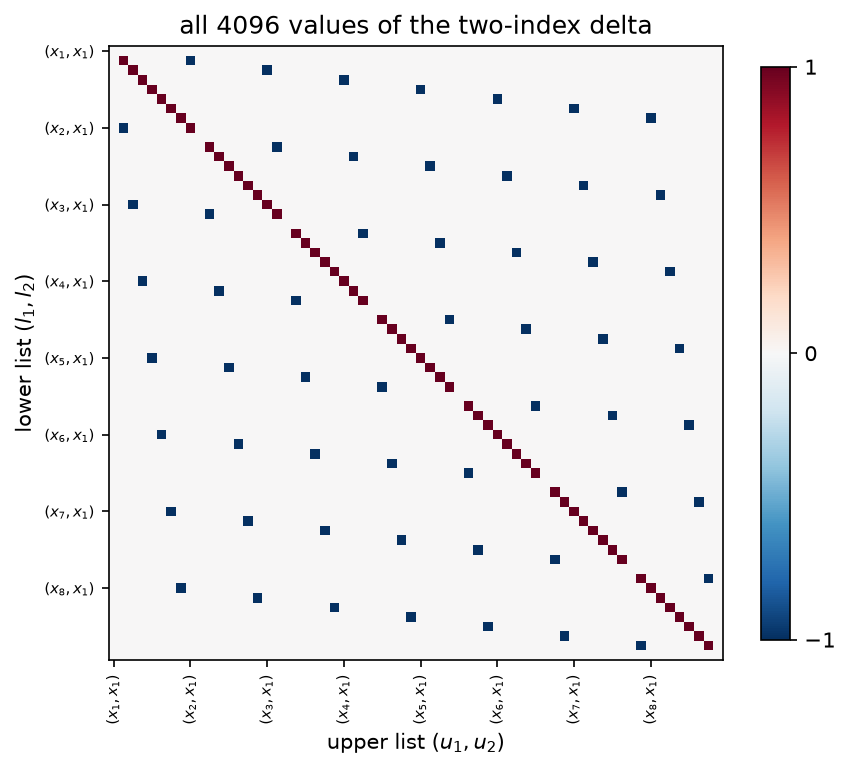

Figure 01c.2 saved as Revision/textbook/figures/01c_2_two_index_table.png


In [7]:
pairs = list(itertools.product(range(8), repeat=2))  # (0, 0), (0, 1), ..., (7, 7)
table = np.array([[gkd_rule(lo, up) for up in pairs] for lo in pairs])  # 64 x 64
two_term_ok = all(
    gkd_rule(lo, up) == kronecker(lo[0], up[0]) * kronecker(lo[1], up[1])
    - kronecker(lo[0], up[1]) * kronecker(lo[1], up[0])
    for lo in pairs for up in pairs)
check(two_term_ok, "the two-term formula holds for all 4096 pairs of length 2")
say(f"values +1: {(table == 1).sum()}, values -1: {(table == -1).sum()}, "
    f"zeros: {(table == 0).sum()}")
check((table == 1).sum() == 56 and (table == -1).sum() == 56,
      "56 values +1 and 56 values -1 among the 4096")
fig, ax = plt.subplots(figsize=(6.6, 6.2))
image = ax.imshow(table, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
ax.grid(False)
ticks = [8 * k for k in range(8)]  # the first pair of each block of 8
ax.set_xticks(ticks, [f"$(x_{k + 1}, x_1)$" for k in range(8)], rotation=90,
              fontsize=7)
ax.set_yticks(ticks, [f"$(x_{k + 1}, x_1)$" for k in range(8)], fontsize=7)
ax.set_xlabel("upper list $(u_1, u_2)$")
ax.set_ylabel("lower list $(l_1, l_2)$")
ax.set_title("all 4096 values of the two-index delta")
fig.colorbar(image, ax=ax, shrink=0.8, ticks=[-1, 0, 1])
save_figure(fig, "two_index_table",
            "All 4096 values of the generalized delta with two indices over the "
            "eight labels $x_1$ to $x_8$: row $(l_1, l_2)$, column $(u_1, u_2)$, "
            "both running through $(x_1, x_1), (x_1, x_2), \\dots, (x_8, x_8)$ "
            "(the tick marks the first pair of each block of 8); red $+1$, blue "
            "$-1$, white 0. The 56 red dots lie on the diagonal (equal lists of two "
            "different labels), the 56 blue dots where the upper list is the "
            "lower list reversed; the 8 lists with two equal labels give white "
            "gaps on the diagonal.")

## 10. All pairs of index lists of length 1, 2 and 3

The Revision record compared GKD with the author's definition for *every* pair of
index lists of length 1, 2 and 3 over the eight labels: $8^2 = 64$, $8^4 = 4096$
and $8^6$ = 262,144 pairs, 266,304 in all, and recorded how many values are
$+1$, $-1$ and $0$. The next cell does the same with plain Python loops: for every
pair it computes the literal determinant and the fast rule, counts disagreements
and tallies the values. Then it compares the tallies with the record's
`measurements` (the field `gkdComparison` of wolfram-gkd-report.json), and its
number of disagreements, 0, with the record's three exhaustive checks, which also
report 0 mismatches. It keeps every value in an array for the next section. This
cell takes several seconds.

In [8]:
comparison = wolfram_report["measurements"]["gkdComparison"]  # one entry per length
recorded = {entry["p"]: entry for entry in comparison}
plain_values = {}  # length p -> array of all values, lower lists in the outer loop
tallies = {}
total_pairs = 0
mismatches = 0
for p in (1, 2, 3):
    lists = list(itertools.product(range(8), repeat=p))
    values = []
    for lower in lists:
        for upper in lists:
            fast = gkd_rule(lower, upper)
            mismatches += fast != kdelta_literal(lower, upper)
            values.append(fast)
    plain_values[p] = np.array(values)
    total_pairs += len(values)
    tally = {v: int((plain_values[p] == v).sum()) for v in (1, -1, 0)}
    tallies[p] = tally
    in_record = (recorded[p]["plusOne"], recorded[p]["minusOne"], recorded[p]["zero"])
    here = (tally[1], tally[-1], tally[0])
    say(f"length {p}: {len(values)} pairs")
    say(f"    counts of (+1, -1, 0): here {here}, record {in_record}")
    check(here == in_record,
          f"length {p}: the counts of +1, -1 and 0 equal the record",
          record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, check "
                 f"gkd_equals_kdelta_exhaustive_length_{p}")
report("pairs of length 1, 2, 3 compared", total_pairs)
exhaustive = [wolfram_checks[f"gkd_equals_kdelta_exhaustive_length_{p}"]
              for p in (1, 2, 3)]  # the record's three exhaustive comparisons
check(total_pairs == 266304 and mismatches == 0 and all(
      c["verdict"] == "PASS" and "(0 mismatches;" in c["detail"] for c in exhaustive),
      "literal determinant = fast rule for all 266304 pairs of length 1, 2, 3",
      record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, checks "
             "gkd_equals_kdelta_exhaustive_length_1 to 3 (0 mismatches)")

length 1: 64 pairs
    counts of (+1, -1, 0): here (8, 0, 56), record (8, 0, 56)
PASS length 1: the counts of +1, -1 and 0 equal the record
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, check
    gkd_equals_kdelta_exhaustive_length_1
length 2: 4096 pairs
    counts of (+1, -1, 0): here (56, 56, 3984), record (56, 56, 3984)
PASS length 2: the counts of +1, -1 and 0 equal the record
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, check
    gkd_equals_kdelta_exhaustive_length_2
length 3: 262144 pairs
    counts of (+1, -1, 0): here (1008, 1008, 260128), record (1008, 1008, 260128)
PASS length 3: the counts of +1, -1 and 0 equal the record
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, check
    gkd_equals_kdelta_exhaustive_length_3
RESULT pairs of length 1, 2, 3 compared = 266304
PASS literal determinant = fast rule for all 266304 pairs of length 1, 2, 3
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report

## 11. All 16,777,216 pairs of length 4

For length 4 there are $8^8$ = 16,777,216 pairs, too many for a plain Python
loop. The next cell writes both functions again so that numpy treats a whole
block of pairs at once (one index list per row of an array):

- `literal_many` builds all the matrices `Outer` of the block at once (an array of
  True and False of shape pairs $\times p \times p$) and adds the Leibniz terms:
  for each permutation, the term is not zero exactly when all its entries are 1;
- `rule_many` uses a shortcut for the sign. If the lower list $L$ is a re-ordering
  of the upper list $U$, both are re-orderings of the same sorted list $S$. The
  matrix $M_{ij} = \delta(l_i, u_j)$ is then the product $P_L P_U^T$ of the two
  permutation matrices with $(P_L)_{ik} = \delta(l_i, s_k)$ and
  $(P_U)_{jk} = \delta(u_j, s_k)$ (the sum over $k$ has one nonzero term), so
  $\det M = \det P_L \det P_U = \mathrm{sign}(L)\,\mathrm{sign}(U)$, where
  $\mathrm{sign}(L)$ counts the inversions of the list $L$ itself. The other
  cases give 0: a repeated upper label, or different sorted lists.

Before it is trusted, the cell checks both new functions against the plain values
of section 10 for all 266,304 pairs of length 1, 2 and 3.

In [9]:
def all_lists(p):
    """Every index list of length p over the labels 0 ... 7, one per row."""
    return np.array(list(itertools.product(range(8), repeat=p)), dtype=np.int8)


def literal_many(lowers, uppers):
    """The author's definition for many pairs at once (exact whole numbers)."""
    p = lowers.shape[1]
    outer = lowers[:, :, None] == uppers[:, None, :]  # shape (pairs, p, p)
    values = np.zeros(len(lowers), dtype=np.int64)
    rows = np.arange(p)
    for order, order_sign in signed_permutations(p):
        # True where the entries (i, order[i]) of the matrix are all 1
        values += order_sign * outer[:, rows, list(order)].all(axis=1)
    return values


def rule_many(lowers, uppers):
    """The fast rule for many pairs at once."""
    p = lowers.shape[1]
    upper_sorted = np.sort(uppers, axis=1)
    upper_distinct = (np.diff(upper_sorted, axis=1) != 0).all(axis=1)
    same_labels = (np.sort(lowers, axis=1) == upper_sorted).all(axis=1)
    first, second = np.triu_indices(p, 1)  # all pairs of places first < second
    inversions_lower = (lowers[:, first] > lowers[:, second]).sum(axis=1)
    inversions_upper = (uppers[:, first] > uppers[:, second]).sum(axis=1)
    signs = np.where((inversions_lower + inversions_upper) % 2 == 0, 1, -1)
    return np.where(upper_distinct & same_labels, signs, 0)


agree = True
for p in (1, 2, 3):
    lists = all_lists(p)
    lowers = np.repeat(lists, len(lists), axis=0)  # each lower list 8^p times
    uppers = np.tile(lists, (len(lists), 1))  # all upper lists, again and again
    agree &= bool((literal_many(lowers, uppers) == plain_values[p]).all())
    agree &= bool((rule_many(lowers, uppers) == plain_values[p]).all())
check(agree, "the block functions agree with the plain ones on all pairs of "
      "length 1, 2, 3")

PASS the block functions agree with the plain ones on all pairs of length 1, 2, 3


The next cell runs through all 16,777,216 pairs of length 4 in 16 blocks of
256 lower lists times all 4096 upper lists (1,048,576 pairs per block),
computes the literal determinant and the fast rule for each pair, counts the
disagreements and tallies the values. The record's self-test did exactly this
with the Rust program; its file gkd-selftest.json gives the number of pairs and
of mismatches. The cell takes 10 to 30 seconds.

In [10]:
selftest = read_report("gkd-selftest.json")
recorded_selftest = {entry["p"]: entry for entry in selftest["results"]}
lists4 = all_lists(4)  # 4096 lists
tally4 = {1: 0, -1: 0, 0: 0}
mismatches4 = 0
for start in range(0, 4096, 256):
    lowers = np.repeat(lists4[start:start + 256], 4096, axis=0)
    uppers = np.tile(lists4, (256, 1))
    literal = literal_many(lowers, uppers)
    fast = rule_many(lowers, uppers)
    mismatches4 += int((literal != fast).sum())
    for v in (1, -1, 0):
        tally4[v] += int((fast == v).sum())
tallies[4] = tally4
pairs4 = sum(tally4.values())
say(f"length 4: {pairs4} pairs; +1: {tally4[1]}, -1: {tally4[-1]}, 0: {tally4[0]}; "
    f"mismatches {mismatches4}")
report("length 4, counts of the values +1, -1, 0",
       f"{tally4[1]}, {tally4[-1]}, {tally4[0]}")
for p in (1, 2, 3, 4):
    mode, pairs_p, wrong = (recorded_selftest[p]["mode"], recorded_selftest[p]["pairs"],
                            recorded_selftest[p]["mismatches"])
    say(f"record gkd-selftest.json, length {p}: {mode}, {pairs_p} pairs, {wrong} "
        "mismatches")
check(pairs4 == recorded_selftest[4]["pairs"] == 16777216 and
      mismatches4 == recorded_selftest[4]["mismatches"] == 0,
      "all 16777216 pairs of length 4: literal determinant = fast rule",
      record="Revision/gkd_lovelock/results/gkd-selftest.json, length 4 "
             "(exhaustive)")
check(all(recorded_selftest[p]["pairs"] == 8 ** (2 * p) and
          recorded_selftest[p]["mismatches"] == 0 for p in (1, 2, 3)),
      "the record's exhaustive self-tests of length 1, 2, 3 cover 8^(2p) pairs "
      "with no mismatch, as found in section 10",
      record="Revision/gkd_lovelock/results/gkd-selftest.json, lengths 1 to 3")

length 4: 16777216 pairs; +1: 20160, -1: 20160, 0: 16736896; mismatches 0
RESULT length 4, counts of the values +1, -1, 0 = 20160, 20160, 16736896
record gkd-selftest.json, length 1: exhaustive, 64 pairs, 0 mismatches
record gkd-selftest.json, length 2: exhaustive, 4096 pairs, 0 mismatches
record gkd-selftest.json, length 3: exhaustive, 262144 pairs, 0 mismatches
record gkd-selftest.json, length 4: exhaustive, 16777216 pairs, 0 mismatches
PASS all 16777216 pairs of length 4: literal determinant = fast rule
     reproduces Revision/gkd_lovelock/results/gkd-selftest.json, length 4 (exhaustive)
PASS the record's exhaustive self-tests of length 1, 2, 3 cover 8^(2p) pairs with no
    mismatch, as found in section 10
     reproduces Revision/gkd_lovelock/results/gkd-selftest.json, lengths 1 to 3


The next cell draws the counts of the values $+1$, $-1$ and $0$ for the lengths
1 to 4 as bars on a logarithmic scale (each step of the scale multiplies by 10).
Almost all values are 0, and the number of $+1$ equals the number of $-1$ from
length 2 on.

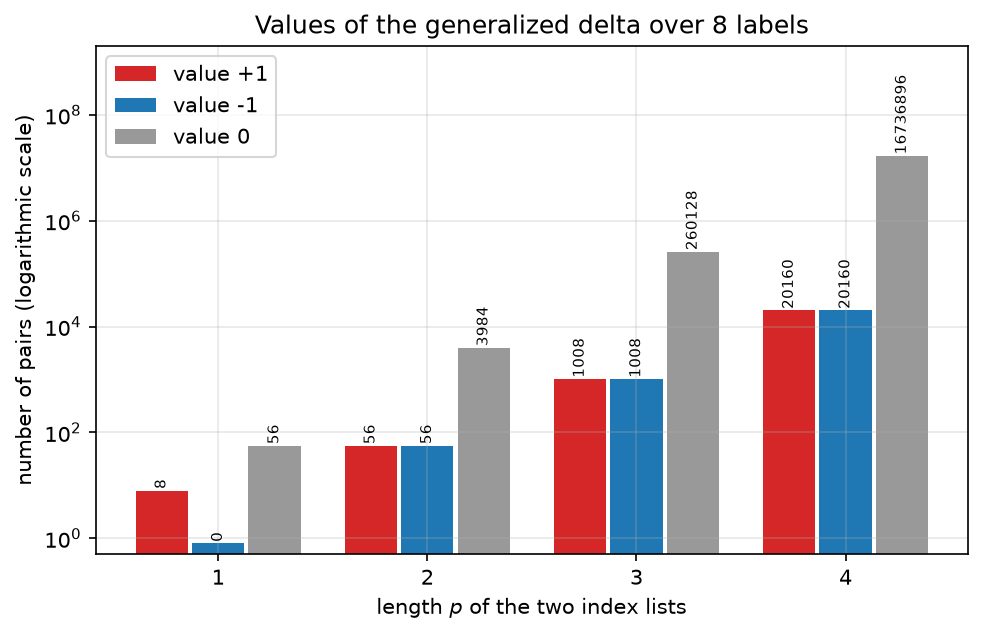

Figure 01c.3 saved as Revision/textbook/figures/01c_3_value_counts.png


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
lengths = np.arange(1, 5)
for shift, value, color, name in [(-0.27, 1, "tab:red", "value +1"),
                                  (0.0, -1, "tab:blue", "value -1"),
                                  (0.27, 0, "0.6", "value 0")]:
    counts = [max(tallies[p][value], 0.8) for p in lengths]  # 0.8 marks a count 0
    ax.bar(lengths + shift, counts, width=0.25, color=color, label=name)
    for x, count in zip(lengths + shift, counts):
        ax.text(x, count * 1.25, f"{count:.0f}" if count >= 1 else "0",
                ha="center", fontsize=7, rotation=90)
ax.set_yscale("log")
ax.set_ylim(0.5, 2e9)
ax.set_xticks(lengths)
ax.set_xlabel("length $p$ of the two index lists")
ax.set_ylabel("number of pairs (logarithmic scale)")
ax.set_title("Values of the generalized delta over 8 labels")
ax.legend(loc="upper left");
save_figure(fig, "value_counts",
            "The number of pairs of index lists of length $p = 1$ to 4 over the "
            "eight labels $x_1$ to $x_8$ for which the generalized delta is $+1$ "
            "(red), $-1$ (blue) and 0 (grey), counted over all $8^{2p}$ pairs; "
            "horizontal axis $p$, vertical axis the number of pairs on a "
            "logarithmic scale, with the exact counts written above the bars "
            "(a count 0 is drawn as a short stub). The counts for $p = 1$ to 3 "
            "equal those of the Revision record.")

## 12. How many values are not zero: a formula

A value is not zero exactly in case (d): the upper list consists of $p$
different labels, and the lower list is a re-ordering of it. There are
$n(n-1)\cdots(n-p+1) = n!/(n-p)!$ upper lists of $p$ different labels from $n$
(the first label has $n$ choices, the second $n - 1$, and so on), and $p!$
re-orderings of each. So

$$N_{\neq 0}(n, p) = \frac{n!}{(n-p)!} \, p! \quad (p \leq n), \qquad
N_{\neq 0}(n, p) = 0 \quad (p > n).$$

For $p \geq 2$ half of the re-orderings are even, so $+1$ and $-1$ occur equally
often; for $p = 1$ every nonzero value is $+1$. The next cell checks the formula
against the counts of sections 9 to 11, prints it for $p = 1$ to 9, and plots the
total number of pairs $n^{2p}$ and the nonzero ones for $n = 8$.

PASS the counting formula n!/(n-p)! p! gives the counts of lengths 1 to 4
p = 1:                   64 pairs,           8 not zero, fraction 1.250e-01
p = 2:                 4096 pairs,         112 not zero, fraction 2.734e-02
p = 3:               262144 pairs,        2016 not zero, fraction 7.690e-03
p = 4:             16777216 pairs,       40320 not zero, fraction 2.403e-03
p = 5:           1073741824 pairs,      806400 not zero, fraction 7.510e-04
p = 6:          68719476736 pairs,    14515200 not zero, fraction 2.112e-04
p = 7:        4398046511104 pairs,   203212800 not zero, fraction 4.621e-05
p = 8:      281474976710656 pairs,  1625702400 not zero, fraction 5.776e-06
p = 9:    18014398509481984 pairs,           0 not zero, fraction 0.000e+00


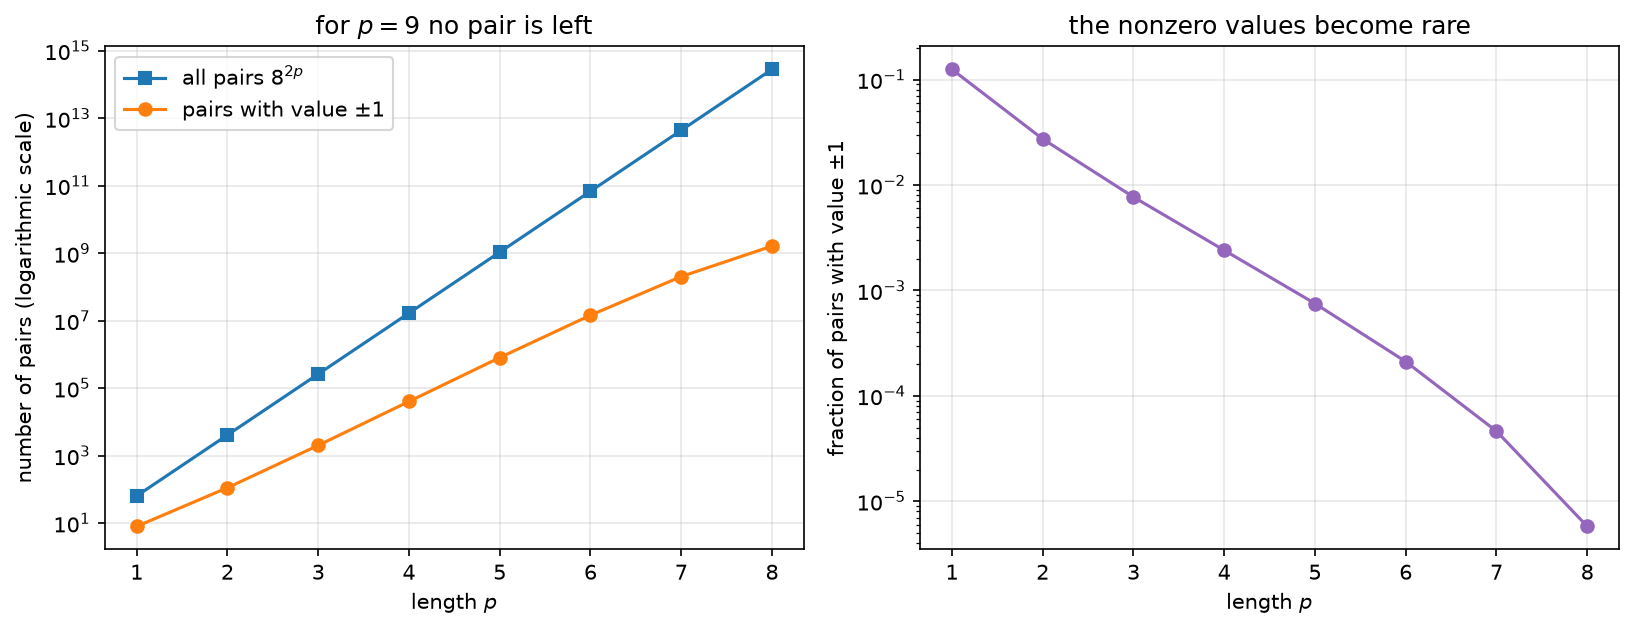

Figure 01c.4 saved as Revision/textbook/figures/01c_4_nonzero_fraction.png


In [12]:
def nonzero_count(n, p):
    """The number of pairs of index lists of length p over n labels with value +-1."""
    return math.perm(n, p) * math.factorial(p) if p <= n else 0


formula_ok = tallies[1][1] == 8 and tallies[1][-1] == 0
for p in (2, 3, 4):
    formula_ok &= tallies[p][1] == tallies[p][-1] == nonzero_count(8, p) // 2
check(formula_ok, "the counting formula n!/(n-p)! p! gives the counts of lengths 1 to 4")
for p in range(1, 10):
    total = 8 ** (2 * p)
    say(f"p = {p}: {total:20d} pairs, {nonzero_count(8, p):11d} not zero, "
        f"fraction {nonzero_count(8, p) / total:.3e}")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.3))
lengths = np.arange(1, 9)
left.semilogy(lengths, [8.0 ** (2 * p) for p in lengths], "s-",
              label="all pairs $8^{2p}$")
left.semilogy(lengths, [nonzero_count(8, p) for p in lengths], "o-",
              label="pairs with value $\\pm 1$")
left.set_xlabel("length $p$")
left.set_ylabel("number of pairs (logarithmic scale)")
left.set_title("for $p = 9$ no pair is left")
left.legend()
right.semilogy(lengths, [nonzero_count(8, p) / 8.0 ** (2 * p) for p in lengths], "o-",
               color="tab:purple")
right.set_xlabel("length $p$")
right.set_ylabel("fraction of pairs with value $\\pm 1$")
right.set_title("the nonzero values become rare")
fig.tight_layout()
# The fraction for p = 8 written as "5.8 \times 10^{-6}" for the caption:
mantissa, exponent = f"{nonzero_count(8, 8) / 8 ** 16:.1e}".split("e")
save_figure(fig, "nonzero_fraction",
            "Left: the number of all pairs of index lists of length $p$ over 8 "
            "labels, $8^{2p}$ (squares), and of the pairs whose generalized delta "
            "is not zero, $8!/(8-p)! \\cdot p!$ (circles), for $p = 1$ to 8, on a "
            "logarithmic scale; for $p = 9$ the second number is 0. Right: their "
            "ratio, the fraction of nonzero values, which falls from $1/8$ at "
            f"$p = 1$ to about ${mantissa} \\times 10^{{{int(exponent)}}}$ at "
            "$p = 8$; horizontal axes the length $p$.")

## 13. Nine indices in eight dimensions

A list of 9 labels taken from only 8 must repeat a label (pigeonhole principle),
so case (a) or (b) applies and the value is 0, for every one of the $8^{18}$
pairs. This is why the Lovelock sum of the author's theory stops at $k = 3$: the
term $k = 4$ would need $2k + 1 = 9$ indices. The next cell confirms it on 300
pairs of random lists of 9 labels (numpy's random generator with the seed 12345)
and on 300 pairs in which the lower list is a re-ordering of the upper one; here
the literal determinant of the $9 \times 9$ matrix (which would have $9!$ =
362,880 Leibniz terms) is computed with numpy's elimination. With 8 labels a
nonzero value is still possible: the cell prints the value for the list
$(x_1, \dots, x_8)$ against its reverse, which has 28 inversions.

In [13]:
generator = np.random.default_rng(12345)
nine_all_zero = True
for sample in range(600):
    upper = tuple(int(x) for x in generator.integers(0, 8, size=9))
    if sample % 2 == 0:  # an arbitrary lower list
        lower = tuple(int(x) for x in generator.integers(0, 8, size=9))
    else:  # a re-ordering of the upper list
        lower = tuple(int(x) for x in generator.permutation(np.array(upper)))
    determinant = np.linalg.det(np.array(outer_matrix(lower, upper), dtype=float))
    nine_all_zero &= gkd_rule(lower, upper) == 0 and abs(determinant) < 1e-9
check(nine_all_zero, "600 pairs of lists of 9 labels from 8: every value is 0",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, check "
             "gkd_nine_indices_in_eight_dimensions_vanish (with our own random lists)")
eight = tuple(range(8))
reverse = eight[::-1]  # (7, 6, ..., 0)
say(f"8 labels against their reverse: {inversions(reverse)} inversions, value "
    f"{gkd_rule(eight, reverse):+d}")
check(gkd_rule(eight, reverse) == 1 and inversions(reverse) == 28,
      "with 8 labels a nonzero value is possible (the reverse order has 28 "
      "inversions, value +1)")

PASS 600 pairs of lists of 9 labels from 8: every value is 0
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    gkd_nine_indices_in_eight_dimensions_vanish (with our own random lists)
8 labels against their reverse: 28 inversions, value +1
PASS with 8 labels a nonzero value is possible (the reverse order has 28 inversions,
    value +1)


## 14. Contracting one index: the factor $n - p + 1$

Take lists $A = (a_1, \dots, a_{p-1})$ and $B = (b_1, \dots, b_{p-1})$, append the
same label $c$ to both, and add over all $n$ values of $c$. The claim is

$$\sum_{c} \delta^{a_1 \dots a_{p-1} c}_{b_1 \dots b_{p-1} c}
= (n - p + 1)\, \delta^{a_1 \dots a_{p-1}}_{b_1 \dots b_{p-1}}.$$

Proof by cases. If $A$ or $B$ repeats a label, every term repeats it too: all
terms are 0, and so is the right side. If $A$ and $B$ consist of different labels
but are not re-orderings of each other, then for each $c$ the extended lists are
not re-orderings of each other either (if $c$ is among the labels of $A$ or $B$
it is repeated; if not, adding it to both changes nothing): all terms are 0. If
$B$ is a re-ordering $\sigma$ of $A$: for the $p - 1$ values of $c$ that are among
the labels, the extended lists repeat $c$ (term 0); for each of the other
$n - (p - 1)$ values, the extended lists are re-ordered by $\sigma$ with $c$ left
in place, which has the same inversions, so each such term equals
$\mathrm{sign}(\sigma)$. Together: $(n - p + 1)\,\mathrm{sign}(\sigma)$.

The next cell checks this for $n = 8$ and $p = 1$ to 8 (exhaustively up to
$p = 4$, with the block function for $p = 4$; for $p = 5$ to 8 on 4000 random
pairs, half of them re-orderings) and for $n = 4$ and $p = 1$ to 4
(exhaustively). For each $(n, p)$ it records the factor found; for $p = 1$ the
empty lists have the value 1 (the determinant of the empty matrix).

In [14]:
def contraction_factors(n, p, pairs_of_lists):
    """The set of the ratios sum_c delta(A + c, B + c) / delta(A, B) over the pairs
    with delta(A, B) != 0; returns None if some pair breaks the identity."""
    found_factors = set()
    for lower, upper in pairs_of_lists:
        total = sum(gkd_rule(lower + (c,), upper + (c,)) for c in range(n))
        base = gkd_rule(lower, upper)
        if base == 0:
            if total != 0:
                return None
        else:
            found_factors.add(total // base)
            if total != (n - p + 1) * base:
                return None
    return found_factors


factors = {}  # (n, p) -> the factor found
for n in (4, 8):
    for p in range(1, n + 1):
        q = p - 1  # the length of the lists A and B
        if (n == 8 and p <= 3) or n == 4:  # every pair of lists, plain loops
            lists = list(itertools.product(range(n), repeat=q))
            pairs_q = [(lo, up) for lo in lists for up in lists]
        elif n == 8 and p == 4:  # every pair, with the block function
            lists = all_lists(3)
            lowers = np.repeat(lists, len(lists), axis=0)
            uppers = np.tile(lists, (len(lists), 1))
            base = rule_many(lowers, uppers)  # delta(A, B) for all 262144 pairs
            total = sum(rule_many(np.column_stack([lowers, np.full(len(lowers), c)]),
                                  np.column_stack([uppers, np.full(len(uppers), c)]))
                        for c in range(8))  # the sum over c, for all pairs at once
            nonzero = base != 0
            ratios = np.unique(total[nonzero] // base[nonzero])  # base is +1 or -1
            identity_holds = (bool((total[~nonzero] == 0).all()) and len(ratios) == 1
                              and bool((total == (n - p + 1) * base).all()))
            factors[(n, p)] = int(ratios[0]) if identity_holds else None
            continue
        else:  # random pairs: half re-orderings of different labels, half arbitrary
            pairs_q = []
            for sample in range(4000):
                if sample % 2 == 0:
                    upper = tuple(int(x) for x in generator.permutation(n)[:q])
                    lower = tuple(int(x) for x in generator.permutation(np.array(upper)))
                else:
                    upper = tuple(int(x) for x in generator.integers(0, n, size=q))
                    lower = tuple(int(x) for x in generator.integers(0, n, size=q))
                pairs_q.append((lower, upper))
        found = contraction_factors(n, p, pairs_q)
        factors[(n, p)] = found.pop() if found and len(found) == 1 else None
say("factors found for n = 8, p = 1 ... 8: "
    + ", ".join(str(factors[(8, p)]) for p in range(1, 9)))
say("factors found for n = 4, p = 1 ... 4: "
    + ", ".join(str(factors[(4, p)]) for p in range(1, 5)))
report("contraction factors for 8 labels, p = 1 to 8",
       ", ".join(str(factors[(8, p)]) for p in range(1, 9)))
check(all(factors[(n, p)] == n - p + 1 for n in (4, 8) for p in range(1, n + 1)),
      "contracting one index multiplies by n - p + 1 (n = 4 and 8, every p)")

factors found for n = 8, p = 1 ... 8: 8, 7, 6, 5, 4, 3, 2, 1
factors found for n = 4, p = 1 ... 4: 4, 3, 2, 1
RESULT contraction factors for 8 labels, p = 1 to 8 = 8, 7, 6, 5, 4, 3, 2, 1
PASS contracting one index multiplies by n - p + 1 (n = 4 and 8, every p)


For the Lovelock tensor of order $k$ the delta has $p = 2k + 1$ indices, and the
trace $\sum_h P_{(k)}{}^h{}_h$ contracts the first upper with the first lower
index (moving them to the end of both lists re-orders rows and columns in the
same way, which changes the sign twice, that is not at all). With $n = 8$ the
factor is $n - p + 1 = 8 - 2k$: 6, 4 and 2 for $k = 1, 2, 3$. The Wolfram report
of the record names its trace checks after these factors
(`k1_trace_equals_6_L1` and so on). The next cell reads the names, takes the
factors out of them and compares them with the factors just found.

In [15]:
trace_checks = [c for c in wolfram_report["checks"]
                if re.fullmatch(r"k\d_trace_equals_\d_L\d", c["name"])]
named = {}
for c in trace_checks:
    name, verdict = c["name"], c["verdict"]
    k_text, factor_text = re.fullmatch(r"k(\d)_trace_equals_(\d)_L\d", name).groups()
    k = int(k_text)
    named[k] = int(factor_text)
    say(f"record check {name}: {verdict}; factor for k = {k}: {factor_text}; "
        f"found here for p = {2 * k + 1}: {factors[(8, 2 * k + 1)]}")
check(named == {1: 6, 2: 4, 3: 2} and
      all(factors[(8, 2 * k + 1)] == named[k] for k in (1, 2, 3)) and
      all(c["verdict"] == "PASS" for c in trace_checks),
      "the factors 8 - 2k = 6, 4, 2 of the Lovelock trace identities",
      record="Revision/gkd_lovelock/results/wolfram-gkd-report.json, checks "
             "k1_trace_equals_6_L1, k2_trace_equals_4_L2, k3_trace_equals_2_L3")

record check k1_trace_equals_6_L1: PASS; factor for k = 1: 6; found here for p = 3: 6
record check k2_trace_equals_4_L2: PASS; factor for k = 2: 4; found here for p = 5: 4
record check k3_trace_equals_2_L3: PASS; factor for k = 3: 2; found here for p = 7: 2
PASS the factors 8 - 2k = 6, 4, 2 of the Lovelock trace identities
     reproduces Revision/gkd_lovelock/results/wolfram-gkd-report.json, checks
    k1_trace_equals_6_L1, k2_trace_equals_4_L2, k3_trace_equals_2_L3


The next cell plots the factors found against $p$ for $n = 8$ and $n = 4$,
together with the straight lines $n - p + 1$, and marks the three values of the
Lovelock trace identities.

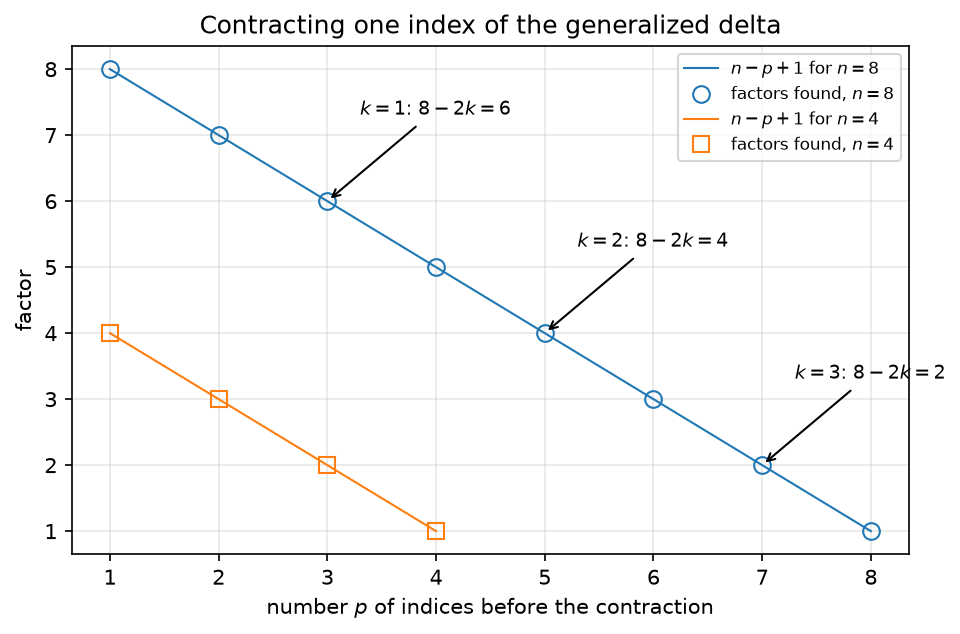

Figure 01c.5 saved as Revision/textbook/figures/01c_5_contraction_factor.png


In [16]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for n, marker, color in ((8, "o", "tab:blue"), (4, "s", "tab:orange")):
    p_values = np.arange(1, n + 1)
    ax.plot(p_values, n - p_values + 1, "-", color=color, lw=1,
            label=f"$n - p + 1$ for $n = {n}$")
    ax.plot(p_values, [factors[(n, p)] for p in p_values], marker, color=color,
            ms=8, fillstyle="none", label=f"factors found, $n = {n}$")
for k in (1, 2, 3):
    ax.annotate(f"$k = {k}$: $8 - 2k = {8 - 2 * k}$", xy=(2 * k + 1, 8 - 2 * k),
                xytext=(2 * k + 1.3, 8 - 2 * k + 1.3), fontsize=9,
                arrowprops={"arrowstyle": "->", "color": "black"})
ax.set_xlabel("number $p$ of indices before the contraction")
ax.set_ylabel("factor")
ax.set_title("Contracting one index of the generalized delta")
ax.legend(loc="upper right", fontsize=8);
save_figure(fig, "contraction_factor",
            "The factor by which contracting one upper with one lower index "
            "multiplies the generalized delta with $p$ indices, found by the checks "
            "of this notebook (open circles for $n = 8$ labels, open squares for "
            "$n = 4$), and the lines $n - p + 1$; horizontal axis $p$, vertical "
            "axis the factor. The arrows mark $p = 2k + 1 = 3, 5, 7$ in eight "
            "dimensions, where the factors $8 - 2k = 6, 4, 2$ are those of the "
            "Lovelock trace identities of the Revision record.")

## 15. The Levi-Civita symbol and the author's second route

The Levi-Civita symbol $\varepsilon_{i_1 \dots i_n}$ is the generalized delta
with the upper list $(0, 1, \dots, n - 1)$: by case (d) it is the sign of the
list if the list is a re-ordering of all $n$ labels, and 0 otherwise. The
author's notebook builds the generalized delta also from two of them (input cell
In[32]: `epsilong[-a, -f, ...] epsilong[b, f, ...] / (8 - 1)!`). The general
formula is

$$\sum_{c_{p+1}, \dots, c_n} \varepsilon_{a_1 \dots a_p c_{p+1} \dots c_n}\,
\varepsilon_{b_1 \dots b_p c_{p+1} \dots c_n}
= (n - p)!\; \delta^{b_1 \dots b_p}_{a_1 \dots a_p}.$$

It is the contraction identity of section 14 used $n - p$ times, starting from
$\varepsilon_{a_1 \dots a_n} \varepsilon_{b_1 \dots b_n}
= \delta^{b_1 \dots b_n}_{a_1 \dots a_n}$ (both sides are the product of the
signs of the two lists, or 0), with the factors $1, 2, \dots, n - p$.

In the author's coordinates the second $\varepsilon$ has upper indices, raised
with the metric; raising all $n$ indices of $\varepsilon$ multiplies it by the
product of the diagonal entries of $\eta^{-1}$, which is $\det \eta = +1$ for the
four $+1$ and four $-1$ of $\eta$ (in four-dimensional spacetime, with one $-1$,
the same step gives a factor $-1$). The author's notebook uses the Levi-Civita
tensor `epsilong` of a metric $g$ that it declares in the cell In[29] with
`DefMetric[{4, 4, 0}, ...]`: four positive, four negative and no zero
eigenvalues, the signature (4,4). For that tensor the factor is the sign of
$\det g$, which is $(+1)^4 (-1)^4 = +1$, the same as for $\eta$ (and for the
author's metric of the Revision record, $\det g = \cos^2 z > 0$).
The next cell reads $\eta$ from the Revision record and checks
$\det\eta = +1$; checks the declaration (4, 4, 0) in the cell In[29]; checks
the formula for $n = 4$ and every $p = 0$ to 4 over all lists; and repeats the
author's In[32] for $n = 8$ and $p = 1$: for all 64 pairs $(a, b)$ it adds the
products over all lists $(c_2, \dots, c_8)$ of 7 different labels and divides by
$7! = 5040$; the result must be the $8 \times 8$ identity matrix $\delta^b_a$.

In [17]:
def levi_civita(indices, n):
    """epsilon_(indices): the generalized delta with the upper list 0, 1, ..., n-1."""
    return gkd_rule(tuple(indices), tuple(range(n)))


eta = json.loads(repository_file("Revision/algebra/gammas.json")
                 .read_text(encoding="utf-8"))["eta"]
say(f"diagonal of eta (x1 ... x8) from the record: {eta}; det eta = {math.prod(eta)}")
check(math.prod(eta) == 1, "det eta = +1: raising all 8 indices of epsilon gives no "
      "extra sign in the signature (4,4)")
# (4, 4, 0): 4 positive, 4 negative, 0 zero eigenvalues; sign of det g = (-1)^4
signature = re.search(r"DefMetric\[\{(\d), (\d), (\d)\}", metric_cell)
positive, negative, zero = (int(part) for part in signature.groups())
say(f"the author's metric g: {positive} positive, {negative} negative, {zero} zero "
    f"eigenvalues; sign of det g = (-1)^{negative} = {(-1) ** negative:+d}")
check((positive, negative, zero) == (4, 4, 0) and (-1) ** negative == 1,
      "the author's notebook declares its metric with the signature (4,4), so the "
      "product of two Levi-Civita tensors has the sign +1",
      record="Revision/gkd_lovelock/results/notebook-input-cells.txt, In[29]")
formula_ok = True
for p in range(0, 5):  # n = 4, every length p of the lists a and b
    lists = list(itertools.product(range(4), repeat=p))
    for a in lists:
        for b in lists:
            total = sum(levi_civita(a + c, 4) * levi_civita(b + c, 4)
                        for c in itertools.product(range(4), repeat=4 - p))
            formula_ok &= total == math.factorial(4 - p) * gkd_rule(a, b)
check(formula_ok, "n = 4: sum of epsilon epsilon = (n - p)! delta for p = 0 to 4, "
      "all lists")
route_sums = np.zeros((8, 8), dtype=np.int64)
for a in range(8):
    others = [label for label in range(8) if label != a]
    for b in range(8):
        # Only lists c of 7 different labels other than a give a nonzero first factor.
        route_sums[a, b] = sum(levi_civita((a,) + c, 8) * levi_civita((b,) + c, 8)
                               for c in itertools.permutations(others))
author_route = route_sums // math.factorial(7)  # divide by 7! = 5040
say(f"the sums for a = b are {sorted(set(np.diag(route_sums).tolist()))}, "
    f"for a different from b {sorted(set(route_sums[~np.eye(8, dtype=bool)].tolist()))}")
check((route_sums == math.factorial(7) * np.eye(8, dtype=np.int64)).all(),
      "the author's route In[32]: sum of epsilon epsilon / 7! = delta^b_a, the "
      "8 x 8 identity")

diagonal of eta (x1 ... x8) from the record: [1, 1, 1, -1, -1, -1, -1, 1]; det eta = 1
PASS det eta = +1: raising all 8 indices of epsilon gives no extra sign in the signature
    (4,4)
the author's metric g: 4 positive, 4 negative, 0 zero eigenvalues; sign of det g = (-1)^4
    = +1
PASS the author's notebook declares its metric with the signature (4,4), so the product
    of two Levi-Civita tensors has the sign +1
     reproduces Revision/gkd_lovelock/results/notebook-input-cells.txt, In[29]
PASS n = 4: sum of epsilon epsilon = (n - p)! delta for p = 0 to 4, all lists
the sums for a = b are [5040], for a different from b [0]
PASS the author's route In[32]: sum of epsilon epsilon / 7! = delta^b_a, the 8 x 8
    identity


The next cell draws the Levi-Civita symbol of three labels as three $3 \times 3$
heat maps (one for each value of the first index; the six nonzero entries are the
signs of the six permutations) and the $8 \times 8$ result of the author's route,
the identity matrix $\delta^b_a$.

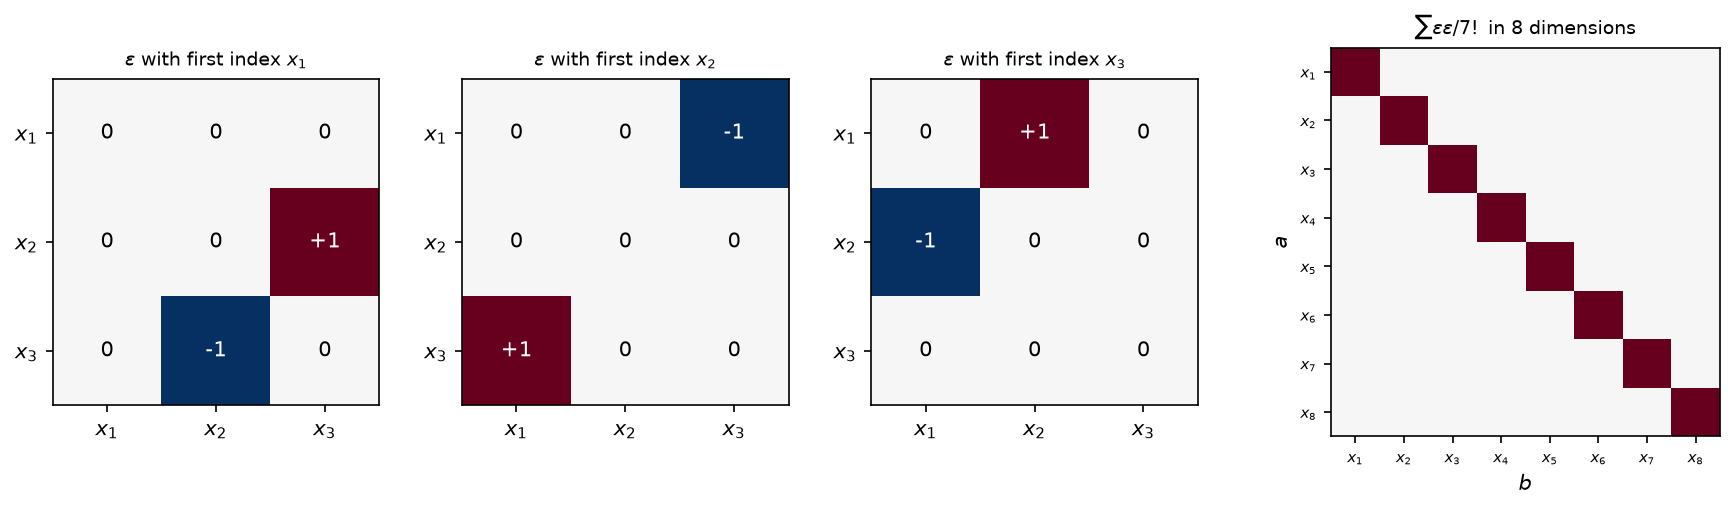

Figure 01c.6 saved as Revision/textbook/figures/01c_6_levi_civita.png


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(12.0, 3.5),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
names3 = ["$x_1$", "$x_2$", "$x_3$"]
for first in range(3):
    ax = axes[first]
    slice_values = np.array([[levi_civita((first, j, k), 3) for k in range(3)]
                             for j in range(3)])
    ax.imshow(slice_values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.grid(False)
    for j in range(3):
        for k in range(3):
            ax.text(k, j, signed(int(slice_values[j, k])), ha="center", va="center",
                    color="white" if slice_values[j, k] else "black")
    ax.set_xticks(range(3), names3)
    ax.set_yticks(range(3), names3)
    ax.set_title(f"$\\varepsilon$ with first index $x_{first + 1}$", fontsize=9)
image = axes[3].imshow(author_route, cmap="RdBu_r", vmin=-1, vmax=1)
axes[3].grid(False)
eight_names = [f"$x_{k}$" for k in range(1, 9)]
axes[3].set_xticks(range(8), eight_names, fontsize=7)
axes[3].set_yticks(range(8), eight_names, fontsize=7)
axes[3].set_xlabel("$b$")
axes[3].set_ylabel("$a$")
axes[3].set_title("$\\sum \\varepsilon\\varepsilon / 7!$ in 8 dimensions", fontsize=9)
fig.tight_layout()
save_figure(fig, "levi_civita",
            "Left three panels: the Levi-Civita symbol $\\varepsilon_{ijk}$ of the "
            "three labels $x_1, x_2, x_3$, one panel for each first index $i$ "
            "(rows $j$, columns $k$; red $+1$, blue $-1$, white 0); its six "
            "nonzero entries are the signs of the six orderings. Right: the "
            "author's second route in eight dimensions, the sum over $c_2$ to $c_8$ "
            "of $\\varepsilon_{a c_2 \\dots c_8} \\varepsilon_{b c_2 \\dots c_8}$ "
            "divided by $7!$, for all 64 pairs of labels $a$ (rows) and $b$ "
            "(columns): exactly the identity matrix, the ordinary Kronecker delta.")

## 16. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [19]:
figure_names = ["01c_1_outer_matrices.png", "01c_2_two_index_table.png",
                "01c_3_value_counts.png", "01c_4_nonzero_fraction.png",
                "01c_5_contraction_factor.png", "01c_6_levi_civita.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 28 CHECKS PASSED (notebook 01c)


## 17. What this notebook showed

- The author's generalized Kronecker delta, `Det[Outer[delta, lower, upper]]`,
  written literally in Python, equals the fast rule of the Revision program GKD
  (0 for a repeated or missing label, otherwise the sign of a permutation) for
  every pair of index lists of length 1 to 4 over the eight coordinates
  $x_1, \dots, x_8$: 266,304 + 16,777,216 pairs, no disagreement, the same
  result as the record's self-test.
- The counts of $+1$, $-1$ and $0$ (8, 0, 56; 56, 56, 3984; 1008, 1008, 260128;
  20160, 20160, 16736896 for the lengths 1 to 4) agree with the record and with
  the formula $N_{\neq 0} = 8!/(8-p)! \cdot p!$; every example of the record is
  reproduced.
- With 9 indices in 8 dimensions the delta is always 0 (pigeonhole), so the
  Lovelock sum of the theory stops at $k = 3$.
- Contracting one index multiplies by $n - p + 1$; in eight dimensions and with
  $p = 2k + 1$ this is $8 - 2k = 6, 4, 2$, the factors of the record's Lovelock
  trace identities.
- The Levi-Civita symbol is a generalized delta, and the product of two
  Levi-Civita symbols summed over $n - p$ indices is $(n - p)!$ times the
  generalized delta; in the signature (4,4) of the author's metric raising the
  indices adds no sign ($\det\eta = +1$), and the author's second route gives the
  Kronecker delta exactly.